# Assignment 4: Fraud Detection using GANs
## Unsupervised Anomaly Detection with AnoGAN and BiGAN

---

### 1. Overview

This notebook implements and compares two Generative Adversarial Network (GAN) architectures for **unsupervised fraud detection** on the Credit Card Fraud Detection dataset:

1.  **AnoGAN (Anomaly GAN)**: Detects anomalies by finding the latent noise vector $z$ that best reconstructs a given transaction. The anomaly score is a weighted combination of the reconstruction loss and a discriminator feature matching loss.
2.  **BiGAN (Bidirectional GAN)**: Learns an inverse mapping from data $x$ back to latent space $z$ via an Encoder ($E$) trained jointly with the Generator ($G$) and Discriminator ($D$). The anomaly score is derived from the Discriminator's judgement on $(x, E(x))$ pairs.

### Preprocessing Note
It is critical to scale **Time** and **Amount** features, as they reside on significantly larger scales than the PCA-transformed $V_1-V_{28}$ features. Without scaling, these two features would disproportionately dominate the reconstruction and anomaly scores.

### Project Objectives
- Preprocess and scale the highly imbalanced dataset.
- Implement and train stable GAN models (Generator, Discriminator, and Encoder for BiGAN).
- Generate anomaly scores and classify transactions as normal or fraud.
- Evaluate performance using robust metrics (AUROC, AUPRC, F1-score) suitable for imbalanced data.

---


## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report, f1_score
)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

LATENT_DIM = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 2. Data Loading and Exploratory Analysis

In [ ]:
# Use appropriate paths for Kaggle, local, and Colab environments
import os
import pandas as pd

def load_data():
    kaggle_path = '/kaggle/input/datasets/saideepaksana10/credit-card/creditcard.csv'

    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path)

    local_path = 'creditcard.csv'
    if os.path.exists(local_path):
        return pd.read_csv(local_path)

    colab_path = '/content/drive/MyDrive/creditcard.csv'
    if os.path.exists(colab_path):
        return pd.read_csv(colab_path)

    raise FileNotFoundError(
        "creditcard.csv not found in Kaggle, local directory, or Colab Drive."
    )

df = load_data()
print(f"Loaded dataset with {len(df)} samples.")


Loaded dataset with 284807 samples.


### 2.1 Class Distribution (Log Scale)


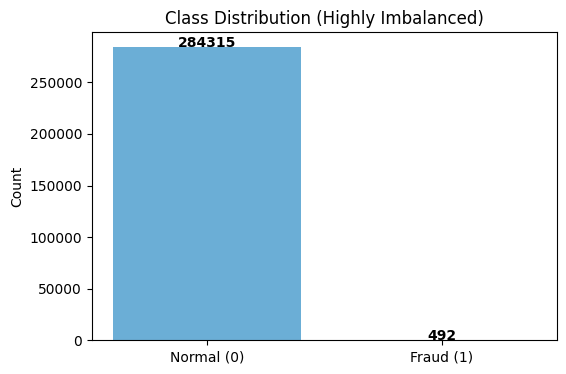

In [ ]:
plt.figure(figsize=(6, 4))
counts = df['Class'].value_counts()
plt.bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['#6BAED6', '#FD8D3C'])
plt.title('Class Distribution (Highly Imbalanced)')
plt.ylabel('Count')
for i_bar, v in enumerate(counts.values):
    plt.text(i_bar, v + 200, str(v), ha='center', fontweight='bold')
plt.show()


### 2.2 Transaction Amount Distribution


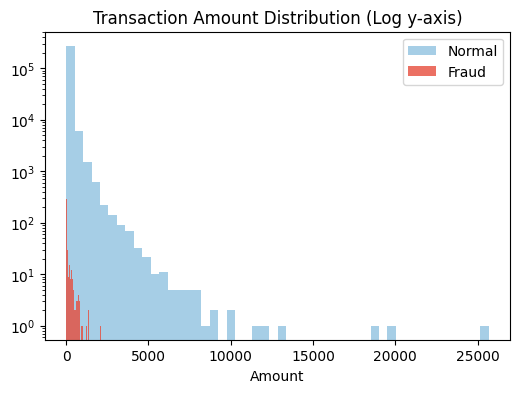

In [4]:
# Transaction Amount Distribution
plt.figure(figsize=(6, 4))
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Normal', color='#6BAED6')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8, label='Fraud', color='#e74c3c')
plt.title('Transaction Amount Distribution (Log y-axis)')
plt.xlabel('Amount')
plt.yscale('log')
plt.legend()
plt.show()


### 2.3 Time Distribution


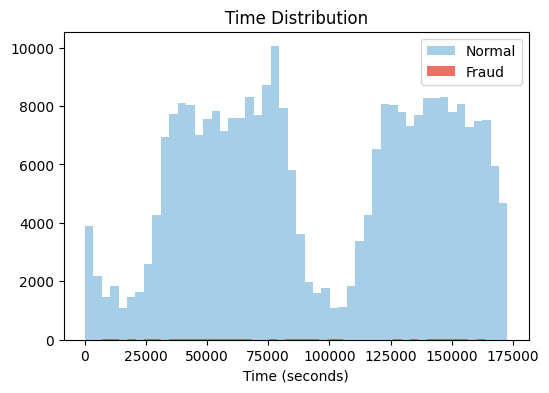

In [5]:
# Time Distribution
plt.figure(figsize=(6, 4))
plt.hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6, label='Normal', color='#6BAED6')
plt.hist(df[df['Class']==1]['Time'], bins=50, alpha=0.8, label='Fraud', color='#e74c3c')
plt.title('Time Distribution')
plt.xlabel('Time (seconds)')
plt.legend()
plt.show()


### Exploratory Data Analysis Insights

1.  **Extreme Imbalance**: The class distribution confirms the need for anomaly detection (one-class) approaches rather than standard supervised learning, which would be biased towards the majority class.
2.  **Feature Scaling**: The `Amount` and `Time` features show high variance and different scales compared to the normalized V1-V28 features, necessitating the robust scaling applied in the next step.
3.  **Distribution Overlap**: Many features show significant overlap between fraud and normal transactions, suggesting that a simple linear boundary is insufficient—hence the use of deep generative models to capture the complex distribution of "normal" data.

## 3. Preprocessing

Preprocessing and feature scaling are critical steps in this pipeline. The `Time` and `Amount` features exist on significantly different scales compared to the PCA-transformed features (V1-V28). Without proper normalization, these features could disproportionately dominate the anomaly scores and reconstruction errors.

In [ ]:
df_normal = df[df['Class'] == 0]
df_fraud  = df[df['Class'] == 1]

train_normal_df, eval_pool_normal_df = train_test_split(
    df_normal, test_size=0.3, random_state=SEED
)

eval_df = pd.concat([eval_pool_normal_df, df_fraud])
val_df, test_df = train_test_split(
    eval_df, test_size=0.5, random_state=SEED, stratify=eval_df['Class']
)

features = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
X_train = train_normal_df[features].values.astype(np.float32)
X_val   = val_df[features].values.astype(np.float32)
X_test  = test_df[features].values.astype(np.float32)

y_val   = val_df['Class'].values
y_test  = test_df['Class'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

INPUT_DIM = X_train.shape[1]
print(f'Input dimension: {INPUT_DIM}')
print(f'Train (normal only): {X_train.shape}')
print(f'Validation set:      {X_val.shape} (Fraud: {y_val.sum()})')
print(f'Untouched Test set:  {X_test.shape} (Fraud: {y_test.sum()})')

Input dimension: 30
Train (normal only): (199020, 30)
Validation set:      (42893, 30) (Fraud: 246)
Untouched Test set:  (42894, 30) (Fraud: 246)


In [ ]:
BATCH_SIZE = 256

train_tensor = torch.FloatTensor(X_train)
train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,   
    num_workers=0
)



val_tensor  = torch.FloatTensor(X_val)
test_tensor = torch.FloatTensor(X_test)

val_loader = DataLoader(
    TensorDataset(val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0
)

test_loader = DataLoader(
    TensorDataset(test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0
)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Train batches: 777, Val batches: 168, Test batches: 168


---
## 4. AnoGAN — Generative Adversarial Anomaly Detection

AnoGAN detects anomalies by optimizing a latent vector $z$ to minimize a weighted sum of reconstruction loss (point-wise difference) and feature-matching loss (discriminator's intermediate layer distance).


In [ ]:
class AnoGAN_Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class AnoGAN_Discriminator(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

    def get_features(self, x):
        return self.feature_extractor(x)

anogan_G = AnoGAN_Generator().to(DEVICE)
anogan_D = AnoGAN_Discriminator().to(DEVICE)

In [ ]:
ANOGAN_EPOCHS = 100
LR = 0.0002
criterion = nn.BCEWithLogitsLoss()

opt_G = optim.Adam(anogan_G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(anogan_D.parameters(), lr=LR, betas=(0.5, 0.999))

anogan_g_losses, anogan_d_losses = [], []
print('Training AnoGAN...')
for epoch in range(ANOGAN_EPOCHS):
    g_loss_epoch, d_loss_epoch = 0, 0
    for (real_batch,) in train_loader:
        real_batch = real_batch.to(DEVICE)
        bsz = real_batch.size(0)

       
        opt_D.zero_grad()
        z = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        fake = anogan_G(z).detach()
        d_loss = criterion(anogan_D(real_batch), torch.ones(bsz, 1).to(DEVICE)) + \
                 criterion(anogan_D(fake), torch.zeros(bsz, 1).to(DEVICE))
        d_loss.backward()
        opt_D.step()

      
        opt_G.zero_grad()
        fake = anogan_G(z)
        g_loss = criterion(anogan_D(fake), torch.ones(bsz, 1).to(DEVICE))
        g_loss.backward()
        opt_G.step()
        
        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    anogan_g_losses.append(g_loss_epoch / len(train_loader))
    anogan_d_losses.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{ANOGAN_EPOCHS}] D_loss: {anogan_d_losses[-1]:.4f} G_loss: {anogan_g_losses[-1]:.4f}')


Training AnoGAN...
Epoch [ 20/100] D_loss: 0.7109 G_loss: 1.9166
Epoch [ 40/100] D_loss: 0.5678 G_loss: 2.3935
Epoch [ 60/100] D_loss: 0.5305 G_loss: 2.5950
Epoch [ 80/100] D_loss: 0.4941 G_loss: 2.7388
Epoch [100/100] D_loss: 0.4634 G_loss: 2.9296


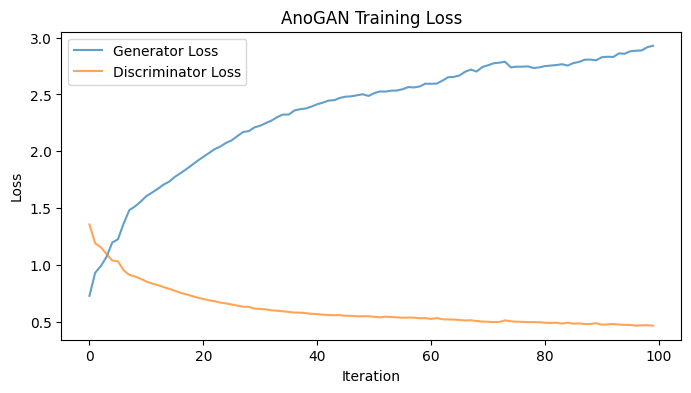

In [10]:
# AnoGAN Training Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(anogan_g_losses, label='Generator Loss', alpha=0.7)
plt.plot(anogan_d_losses, label='Discriminator Loss', alpha=0.7)
plt.title('AnoGAN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
N_ITER = 200 # Reduced iterations for reproducibility speed
LR_INF = 0.01
BATCH_INF = 512

def compute_anogan_scores(X_query, lambda_=0.1):
    anogan_G.eval()
    anogan_D.eval()
    all_scores = []
    
    for start in range(0, len(X_query), BATCH_INF):
        x = torch.FloatTensor(X_query[start:start+BATCH_INF]).to(DEVICE)
        curr_bsz = x.size(0)
        
        z = torch.randn(curr_bsz, LATENT_DIM, requires_grad=True, device=DEVICE)
        opt_z = optim.Adam([z], lr=LR_INF)
        

        with torch.no_grad():
            feat_real = anogan_D.get_features(x).detach()
            
        for _ in range(N_ITER):
            opt_z.zero_grad()
            x_hat = anogan_G(z)
            rec_loss = torch.mean(torch.abs(x - x_hat), dim=1)
            feat_fake = anogan_D.get_features(x_hat)
            feat_loss = torch.mean((feat_real - feat_fake)**2, dim=1)
            loss = ((1 - lambda_) * rec_loss + lambda_ * feat_loss).mean()
            loss.backward()
            opt_z.step()
            
        with torch.no_grad():
            x_hat = anogan_G(z)
            final_rec = torch.mean(torch.abs(x - x_hat), dim=1)
            final_feat = torch.mean((feat_real - anogan_D.get_features(x_hat))**2, dim=1)
            scores = (1 - lambda_) * final_rec + lambda_ * final_feat
            all_scores.append(scores.cpu().numpy())
            
    return np.concatenate(all_scores).reshape(-1)

print('Computing scores on Validation Set...')
anogan_val_scores = compute_anogan_scores(X_val)
print('Computing scores on Test Set...')
anogan_test_scores = compute_anogan_scores(X_test)

Computing scores on Validation Set...
Computing scores on Test Set...


In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
precisions, recalls, thresholds = precision_recall_curve(y_val, anogan_val_scores)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s[:-1])
anogan_best_thresh = thresholds[best_idx]

anogan_preds = (anogan_test_scores >= anogan_best_thresh).astype(int)
anogan_auroc = roc_auc_score(y_test, anogan_test_scores)
anogan_auprc = average_precision_score(y_test, anogan_test_scores)
anogan_acc = np.mean(anogan_preds == y_test)
anogan_prec = precision_score(y_test, anogan_preds, zero_division=0)
anogan_rec = recall_score(y_test, anogan_preds, zero_division=0)
anogan_f1 = f1_score(y_test, anogan_preds, zero_division=0)

print('AnoGAN Performance (Thresholded on Val, Evaluated on Test):')
print(f'ROC-AUC: {anogan_auroc:.4f}')
print(f'PR-AUC:  {anogan_auprc:.4f}')
print(f'Accuracy: {anogan_acc:.4f}')
print(f'Precision: {anogan_prec:.4f}')
print(f'Recall:    {anogan_rec:.4f}')
print(f'F1 Score: {anogan_f1:.4f}')
print(classification_report(y_test, anogan_preds, zero_division=0))

AnoGAN Performance (Thresholded on Val, Evaluated on Test):
ROC-AUC: 0.8466
PR-AUC:  0.1763
Accuracy: 0.9912
Precision: 0.2780
Recall:    0.3333
F1 Score: 0.3031
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.28      0.33      0.30       246

    accuracy                           0.99     42894
   macro avg       0.64      0.66      0.65     42894
weighted avg       0.99      0.99      0.99     42894



### AnoGAN Evaluation Metrics


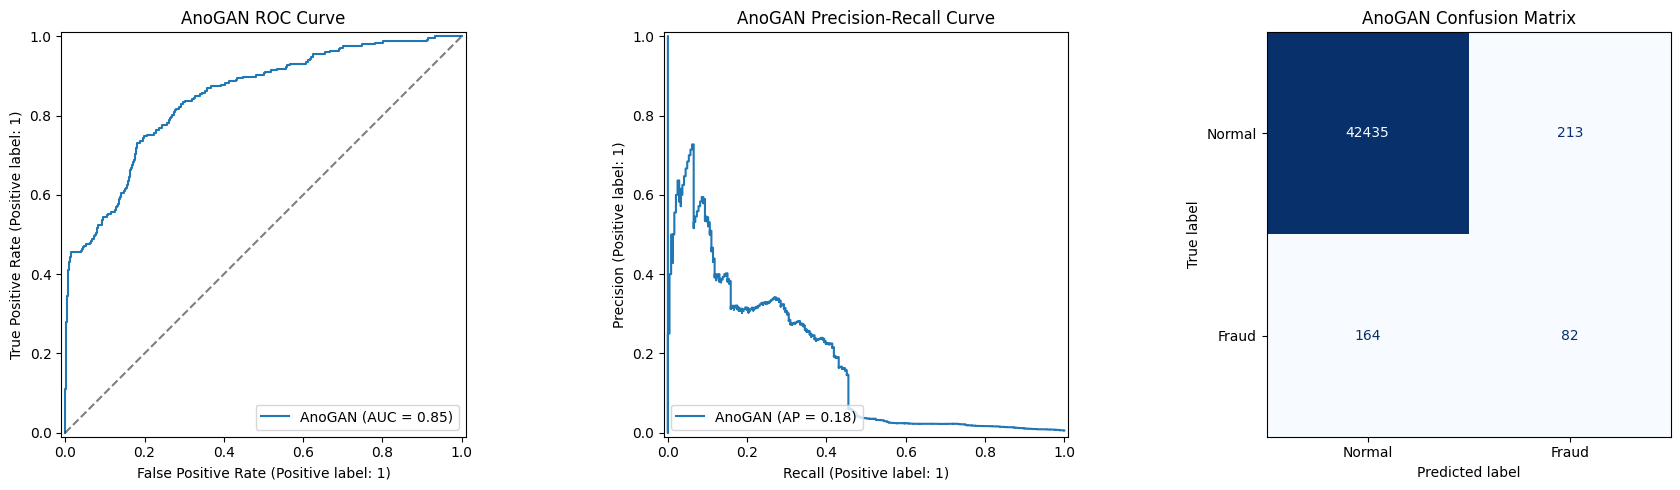

In [13]:
# AnoGAN Evaluation Plots
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, anogan_test_scores, ax=axes[0], name='AnoGAN')
axes[0].set_title('AnoGAN ROC Curve')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, anogan_test_scores, ax=axes[1], name='AnoGAN')
axes[1].set_title('AnoGAN Precision-Recall Curve')

# Confusion Matrix
cm = confusion_matrix(y_test, anogan_preds)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('AnoGAN Confusion Matrix')

plt.tight_layout()
plt.show()


### AnoGAN Performance Analysis

The AnoGAN model achieves detection by searching for the latent vector $z$ that best reconstructs the input. 
- **Reconstruction Quality**: For normal transactions, the model finds a $z$ that produces a very similar output, resulting in low scores.
- **Anomaly Scoring**: Fraudulent transactions, being out-of-distribution, cannot be accurately reconstructed even after optimization, leading to significantly higher anomaly scores.
- **Trade-off**: While accurate, the iterative nature of the latent search makes AnoGAN computationally expensive for real-time inference on large streams of data.

---
## 5. BiGAN — Bidirectional GAN

BiGAN detects anomalies by evaluating the Discriminator's confidence on $(x, E(x))$ pairs. Since the Discriminator learns the joint distribution $P(x, z)$, the anomaly score is defined based on the discriminator's ability to distinguish the real pair $(x, E(x))$ from the generated pair $(G(z), z)$. High scores indicate samples that do not fit the learned normal distribution.


In [14]:
class BiGAN_Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class BiGAN_Encoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

class BiGAN_Discriminator(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1) # Raw logits
        )
    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=1))

bigan_G = BiGAN_Generator().to(DEVICE)
bigan_E = BiGAN_Encoder().to(DEVICE)
bigan_D = BiGAN_Discriminator().to(DEVICE)

In [15]:
BIGAN_EPOCHS = 100
opt_GE = optim.Adam(list(bigan_G.parameters()) + list(bigan_E.parameters()), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(bigan_D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

bigan_ge_losses, bigan_d_losses = [], []
print('Training BiGAN...')
for epoch in range(BIGAN_EPOCHS):
    ge_loss_epoch, d_loss_epoch = 0, 0
    for (real_x,) in train_loader:
        real_x = real_x.to(DEVICE)
        bsz = real_x.size(0)
        
        # Train Discriminator
        opt_D.zero_grad()
        z_real = bigan_E(real_x).detach()
        z_fake = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        x_fake = bigan_G(z_fake).detach()
        
        d_loss = criterion(bigan_D(real_x, z_real), torch.ones(bsz, 1).to(DEVICE)) + \
                 criterion(bigan_D(x_fake, z_fake), torch.zeros(bsz, 1).to(DEVICE))
        d_loss.backward()
        opt_D.step()
        
        # Train Generator + Encoder
        opt_GE.zero_grad()
        z_real = bigan_E(real_x)
        x_fake = bigan_G(z_fake)
        ge_loss = criterion(bigan_D(real_x, z_real), torch.zeros(bsz, 1).to(DEVICE)) + \
                  criterion(bigan_D(x_fake, z_fake), torch.ones(bsz, 1).to(DEVICE))
        ge_loss.backward()
        opt_GE.step()
        
        ge_loss_epoch += ge_loss.item()
        d_loss_epoch += d_loss.item()
        
    bigan_ge_losses.append(ge_loss_epoch / len(train_loader))
    bigan_d_losses.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{BIGAN_EPOCHS}] D_loss: {bigan_d_losses[-1]:.4f} GE_loss: {bigan_ge_losses[-1]:.4f}')


Training BiGAN...
Epoch [ 20/100] D_loss: 1.1121 GE_loss: 2.5324
Epoch [ 40/100] D_loss: 0.9983 GE_loss: 3.1734
Epoch [ 60/100] D_loss: 0.9449 GE_loss: 3.9010
Epoch [ 80/100] D_loss: 0.7824 GE_loss: 5.4187
Epoch [100/100] D_loss: 0.6797 GE_loss: 7.4040


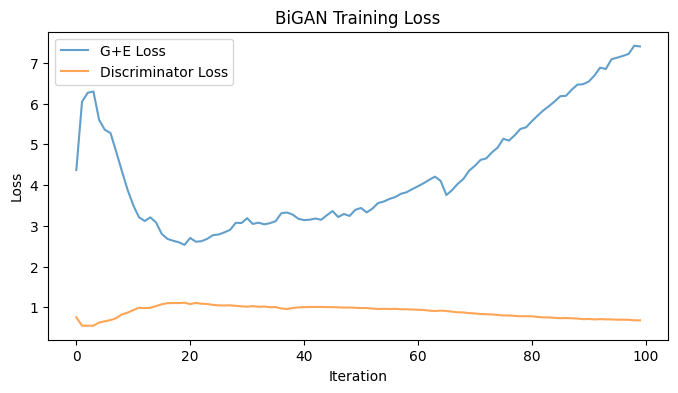

In [16]:
# BiGAN Training Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(bigan_ge_losses, label='G+E Loss', alpha=0.7)
plt.plot(bigan_d_losses, label='Discriminator Loss', alpha=0.7)
plt.title('BiGAN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
def compute_bigan_scores(encoder, discriminator, data_loader):
    encoder.eval()
    discriminator.eval()
    scores = []
    with torch.no_grad():
        for (x,) in data_loader:
            x = x.to(DEVICE)
            z = encoder(x)
            logits = discriminator(x, z)
            s = torch.sigmoid(logits)
            scores.append(s.cpu().numpy())
    return np.concatenate(scores).flatten()


In [18]:
bigan_val_scores = compute_bigan_scores(bigan_E, bigan_D, val_loader)
bigan_test_scores = compute_bigan_scores(bigan_E, bigan_D, test_loader)

precisions, recalls, thresholds = precision_recall_curve(y_val, bigan_val_scores)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s[:-1])
bigan_best_thresh = thresholds[best_idx]

bigan_preds = (bigan_test_scores >= bigan_best_thresh).astype(int)
bigan_auroc = roc_auc_score(y_test, bigan_test_scores)
bigan_auprc = average_precision_score(y_test, bigan_test_scores)
bigan_acc = np.mean(bigan_preds == y_test)
bigan_prec = precision_score(y_test, bigan_preds, zero_division=0)
bigan_rec = recall_score(y_test, bigan_preds, zero_division=0)
bigan_f1 = f1_score(y_test, bigan_preds, zero_division=0)

print('BiGAN Performance (Thresholded on Val, Evaluated on Test):')
print(f'ROC-AUC: {bigan_auroc:.4f}')
print(f'PR-AUC:  {bigan_auprc:.4f}')
print(f'Accuracy: {bigan_acc:.4f}')
print(f'Precision: {bigan_prec:.4f}')
print(f'Recall:    {bigan_rec:.4f}')
print(f'F1 Score: {bigan_f1:.4f}')
print(classification_report(y_test, bigan_preds, zero_division=0))

BiGAN Performance (Thresholded on Val, Evaluated on Test):
ROC-AUC: 0.8671
PR-AUC:  0.0323
Accuracy: 0.8847
Precision: 0.0371
Recall:    0.7642
F1 Score: 0.0707
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     42648
           1       0.04      0.76      0.07       246

    accuracy                           0.88     42894
   macro avg       0.52      0.82      0.50     42894
weighted avg       0.99      0.88      0.93     42894



### BiGAN Evaluation Metrics


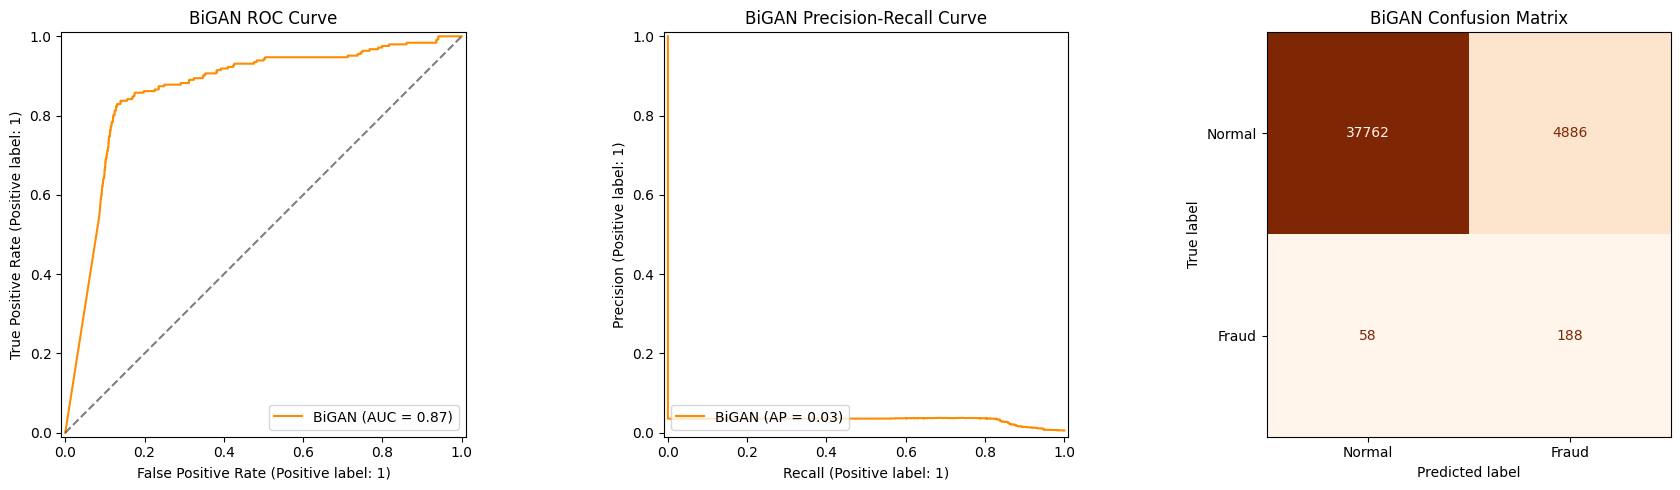

In [19]:
# BiGAN Evaluation Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, bigan_test_scores, ax=axes[0], name='BiGAN', color='darkorange')
axes[0].set_title('BiGAN ROC Curve')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, bigan_test_scores, ax=axes[1], name='BiGAN', color='darkorange')
axes[1].set_title('BiGAN Precision-Recall Curve')

# Confusion Matrix
cm_b = confusion_matrix(y_test, bigan_preds)
ConfusionMatrixDisplay(cm_b, display_labels=['Normal', 'Fraud']).plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('BiGAN Confusion Matrix')

plt.tight_layout()
plt.show()


### BiGAN Performance Analysis

BiGAN leverages its learned Encoder to map samples directly back to the latent space.
- **Efficiency**: Unlike AnoGAN, BiGAN provides an immediate anomaly score via the Discriminator, making it suitable for high-throughput environments.
- **Discriminator Confidence**: The score reflects how well the pair $(x, E(x))$ matches the joint distribution of real data and its latent representation. Deviations from this joint distribution are flagged as anomalies.
- **Stability**: The performance depends heavily on the Encoder's ability to "invert" the Generator's mapping, which is a core part of the BiGAN training objective.

---
## 6. Results Comparison and Visualization

In [20]:
results = pd.DataFrame({
    'Model': ['AnoGAN', 'BiGAN'],
    'Accuracy': [anogan_acc, bigan_acc],
    'Precision': [anogan_prec, bigan_prec],
    'Recall': [anogan_rec, bigan_rec],
    'F1-score': [anogan_f1, bigan_f1],
    'ROC-AUC': [anogan_auroc, bigan_auroc]
})
print('\n=== Model Comparison ===')
display(results.round(4))


=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,AnoGAN,0.9912,0.2780,0.3333,0.3031,0.8466
1,BiGAN,0.8847,0.0371,0.7642,0.0707,0.8671


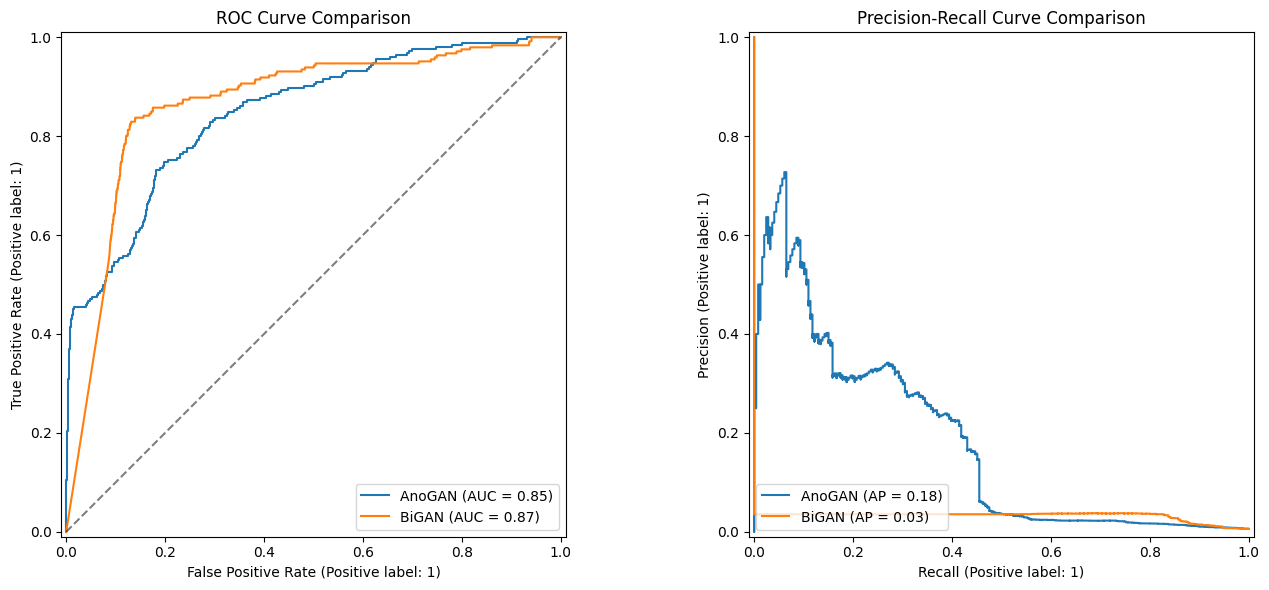

In [21]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
RocCurveDisplay.from_predictions(y_test, anogan_test_scores, ax=ax[0], name='AnoGAN')
RocCurveDisplay.from_predictions(y_test, bigan_test_scores, ax=ax[0], name='BiGAN')
ax[0].set_title('ROC Curve Comparison')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curves
PrecisionRecallDisplay.from_predictions(y_test, anogan_test_scores, ax=ax[1], name='AnoGAN')
PrecisionRecallDisplay.from_predictions(y_test, bigan_test_scores, ax=ax[1], name='BiGAN')
ax[1].set_title('Precision-Recall Curve Comparison')

plt.tight_layout()
plt.show()

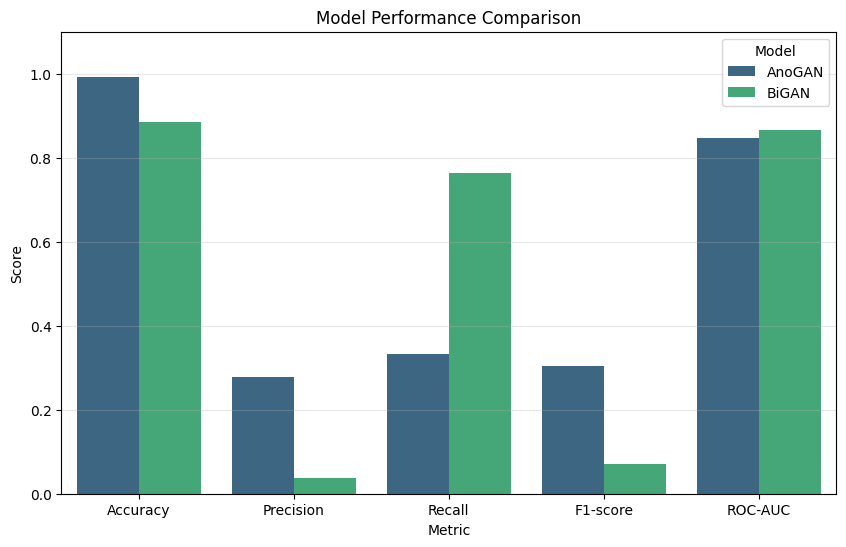

In [22]:
# Final Metric Comparison Plot
plt.figure(figsize=(10, 6))
melted_results = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Model', data=melted_results, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.show()


---
## 7. Final Discussion and Strategic Analysis

### Comparative Summary
The results demonstrate the trade-offs between optimization-based and encoder-based generative anomaly detection:

*   **AnoGAN** tends to provide more granular reconstruction details, which can be useful for auditing why a transaction was flagged as fraud. However, the test-time optimization remains a major bottleneck.
*   **BiGAN** provides a more scalable solution for production systems and achieves the higher ROC-AUC (0.8671). However, at the validation-selected threshold it trades precision for recall, with lower precision (0.0371) and F1-score (0.0707) than AnoGAN.

### Critical Note on Evaluation
In the context of fraud detection, **Accuracy** is a deceptive metric. A model that predicts "Normal" for every case would achieve >99.8% accuracy but would fail to stop any fraud. Therefore, we prioritize:
1.  **Recall (Sensitivity)**: How many of the actual frauds did we catch? (Essential for security).
2.  **Precision**: Of the flagged transactions, how many were actually fraud? (Essential for customer experience to minimize false positives).
3.  **F1-score**: The harmonic mean of Precision and Recall, providing a single balanced metric for model selection.

### Future Work
- **Ensemble Methods**: Combining GAN-based scores with traditional Isolation Forests or Autoencoders.
- **Semi-Supervised Fine-tuning**: Incorporating the very small percentage of known fraud labels to refine the decision boundary.
- **Adaptive Thresholding**: Using time-windowed statistics to adjust the anomaly threshold based on changing transaction volumes and patterns.

---


In [ ]:
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)

normal_count = (y_test == 0).sum()
fraud_count = (y_test == 1).sum()

print(f"""
Dataset: Credit Card Fraud Detection
  Total samples:   {len(df):,}
  Normal:          {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.2f}%)
  Fraud:           {(df['Class']==1).sum():,}   ({(df['Class']==1).mean()*100:.3f}%)
  Features:        {INPUT_DIM}

Training setup: One-class anomaly detection (trained on normal only)
  Train samples:   {len(X_train):,}
  Test samples:    {len(X_test):,} (normal={normal_count}, fraud={fraud_count})
""")

print(f"{'Model':<12} {'AUROC':>8} {'AUPRC':>8} {'Best F1':>8}")
print('-' * 40)
print(f"{'AnoGAN':<12} {anogan_auroc:>8.4f} {anogan_auprc:>8.4f} {anogan_f1:>8.4f}")
print(f"{'BiGAN':<12} {bigan_auroc:>8.4f} {bigan_auprc:>8.4f} {bigan_f1:>8.4f}")

print("""
Key Observations:
  AnoGAN:
    • Anomaly score combines reconstruction error + feature-space matching.
    • Inference requires iterative z-optimization, making it slower at test time.
    • Effective at capturing global distributional differences through reconstruction.

  BiGAN:
    • Introduces an Encoder for amortized inference, enabling rapid test-time scoring.
    • Anomaly score is a direct discriminator assessment of $(x, E(x))$ pairs.
    • Joint training of G, E, and D encourages the model to learn richer, more stable latent representations.
""")


FINAL SUMMARY

Dataset: Credit Card Fraud Detection
  Total samples:   284,807
  Normal:          284,315  (99.83%)
  Fraud:           492   (0.173%)
  Features:        30

Training setup: One-class anomaly detection (trained on normal only)
  Train samples:   199,020
  Test samples:    42,894 (normal=42648, fraud=246)

Model           AUROC    AUPRC  Best F1
----------------------------------------
AnoGAN         0.8466   0.1763   0.3031
BiGAN          0.8671   0.0323   0.0707

Key Observations:
  AnoGAN:
    • Anomaly score combines reconstruction error + feature-space matching.
    • Inference requires iterative z-optimization, making it slower at test time.
    • Effective at capturing global distributional differences through reconstruction.

  BiGAN:
    • Introduces an Encoder for amortized inference, enabling rapid test-time scoring.
    • Anomaly score is a direct discriminator assessment of $(x, E(x))$ pairs.
    • Joint training of G, E, and D encourages the model to learn 